Linear Regression Model

Train size: (1370, 13)
Test size : (381, 13)
MSE        : 17150109.13
RMSE       : 4141.27
R²         : 0.5658
MAE        : 2831.89
Relative MSE : 0.4772
MAPE         : 369.45%


,Datum,Ist,Vorhersage
1370,2024-11-01,10986.60,9950.882993
1371,2024-11-02,15423.80,11524.397796
1372,2024-11-03,9494.20,10234.784097
1373,2024-11-04,3354.00,7563.758751
1374,2024-11-05,5702.30,5831.329882
1375,2024-11-06,4973.30,4750.211448
1376,2024-11-07,5935.70,6089.644497
1377,2024-11-08,9181.20,9942.216420
1378,2024-11-09,14831.50,11428.624701
1379,2024-11-10,12205.60,9060.489846


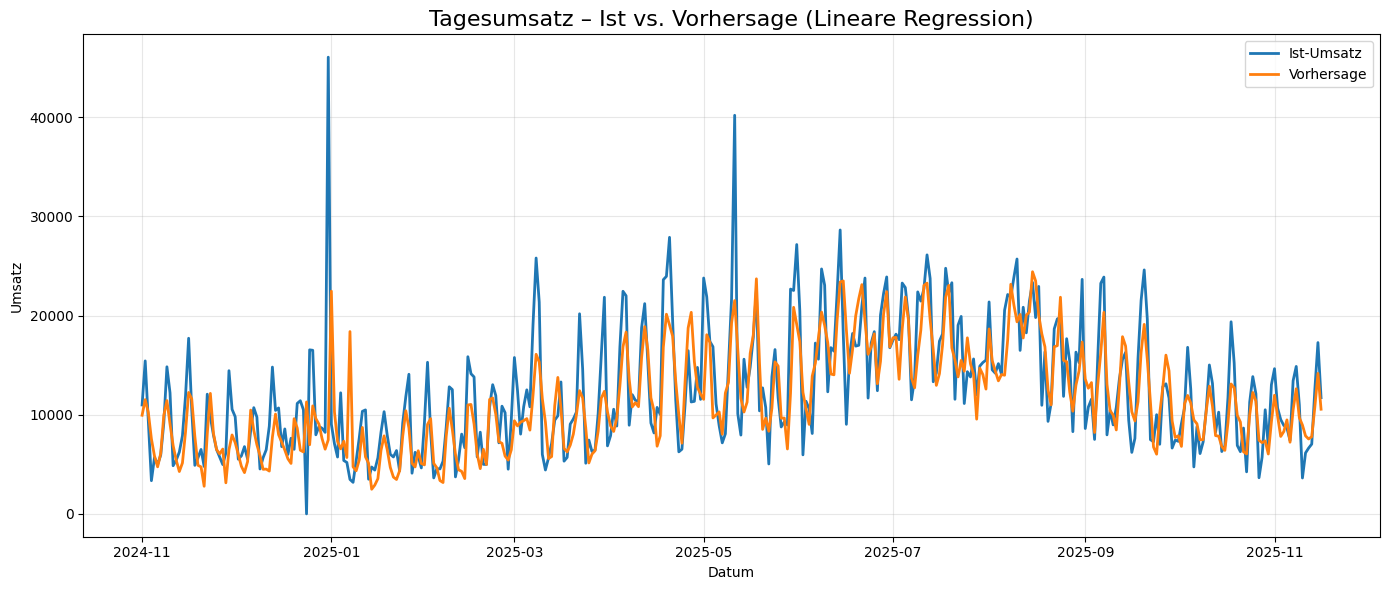

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# ============================================
# 1) Daten laden
# ============================================
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 1.1) Spalten entfernen, die Umsatzbestandteile sind (sonst Data Leakage)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

# Zielvariable
target = "Tagesumsatz Restaurant"

# ============================================
# 2) Lag-Features
# ============================================
df["lag1"] = df[target].shift(1)
df["lag2"] = df[target].shift(2)
df["lag7"] = df[target].shift(7)
df["lag30"] = df[target].shift(30)

# NaN durch Lags entfernen
df = df.dropna().reset_index(drop=True)

# ============================================
# 3) Feature-Auswahl
# ============================================
num_cols = df.select_dtypes(include=["number"]).columns
cols_to_exclude = ["Tagesumsatz Restaurant", "Restaurant", "Terrasse"]
feature_cols = [c for c in num_cols if c not in cols_to_exclude]

X = df[feature_cols]
y = df[[target]]  # als DataFrame für StandardScaler

# ============================================
# 4) Hilfsfunktionen für Weihnachten, Silvester & Muttertag
# ============================================

def mothers_day(year: int) -> pd.Timestamp:
    """Muttertag CH = 2. Sonntag im Mai."""
    may_first = pd.Timestamp(year, 5, 1)
    first_sunday_offset = (6 - may_first.weekday()) % 7  # Monday=0, Sunday=6
    first_sunday = may_first + pd.Timedelta(days=first_sunday_offset)
    second_sunday = first_sunday + pd.Timedelta(days=7)
    return second_sunday

def is_christmas(date: pd.Timestamp) -> bool:
    """Weihnachten: 24.12."""
    return (date.month == 12) and (date.day == 24)

def is_silvester(date: pd.Timestamp) -> bool:
    """Silvester: 31.12."""
    return (date.month == 12) and (date.day == 31)

def is_mothers_day(date: pd.Timestamp) -> bool:
    """Muttertag (CH) für das entsprechende Jahr."""
    return date == mothers_day(date.year)

def is_special_day(date: pd.Timestamp) -> bool:
    """True, wenn Weihnachten ODER Silvester ODER Muttertag."""
    return is_christmas(date) or is_silvester(date) or is_mothers_day(date)

def holiday_average_last_3_years(df_full: pd.DataFrame, date_func, year: int, target_col: str):
    """
    Durchschnitt des Zielwerts am Feiertag der letzten 3 Jahre (year-1, year-2, year-3).
    date_func(year) muss ein Timestamp des Feiertags zurückgeben.
    """
    years = [year - 1, year - 2, year - 3]
    values = []

    for y_ in years:
        d_ = date_func(y_)
        val = df_full.loc[df_full["Datum"] == d_, target_col]
        if len(val) > 0:
            values.append(val.values[0])

    if len(values) == 0:
        return None
    return np.mean(values)

# ============================================
# 5) Zeitbasiertes Train/Test-Split
# ============================================
split_date = pd.Timestamp("2024-11-01")

train_mask = df["Datum"] < split_date
test_mask  = df["Datum"] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# ============================================
# 5b) Weihnachten, Silvester & Muttertag aus TRAINING entfernen
# ============================================
train_dates = df.loc[train_mask, "Datum"]
special_mask_train = train_dates.apply(is_special_day)

X_train = X_train[~special_mask_train]
y_train = y_train[~special_mask_train]

print("Train size (ohne Weihnachten/Silvester/Muttertag):", X_train.shape)
print("Test size                                      :", X_test.shape)

# ============================================
# 6) Standardisierung von X und y
# ============================================
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)

# ============================================
# 7) Modell trainieren
# ============================================
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled.ravel())

# ============================================
# 8) Vorhersagen & Rücktransformation
# ============================================
y_pred_scaled = model.predict(X_test_scaled)

y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_test_original = y_test.values.ravel()

# ============================================
# 8b) Adjust für Weihnachten, Silvester & Muttertag
#      Vorhersage = Durchschnitt der letzten 3 Jahre
# ============================================
y_pred_adjusted = y_pred.copy()
test_dates = df.loc[test_mask, "Datum"].values

for i, d in enumerate(test_dates):
    d = pd.Timestamp(d)
    year = d.year

    # Weihnachten (24.12.)
    if is_christmas(d):
        avg_xmas = holiday_average_last_3_years(
            df_full=df,
            date_func=lambda y_: pd.Timestamp(y_, 12, 24),
            year=year,
            target_col=target
        )
        if avg_xmas is not None:
            y_pred_adjusted[i] = avg_xmas

    # Silvester (31.12.)
    if is_silvester(d):
        avg_silvester = holiday_average_last_3_years(
            df_full=df,
            date_func=lambda y_: pd.Timestamp(y_, 12, 31),
            year=year,
            target_col=target
        )
        if avg_silvester is not None:
            y_pred_adjusted[i] = avg_silvester

    # Muttertag
    if is_mothers_day(d):
        avg_mothers = holiday_average_last_3_years(
            df_full=df,
            date_func=mothers_day,
            year=year,
            target_col=target
        )
        if avg_mothers is not None:
            y_pred_adjusted[i] = avg_mothers

# ============================================
# 9) Metriken mit angepasster Vorhersage
# ============================================
mse = mean_squared_error(y_test_original, y_pred_adjusted)
rmse = mse ** 0.5
r2 = r2_score(y_test_original, y_pred_adjusted)
mae = mean_absolute_error(y_test_original, y_pred_adjusted)

# naive baseline: yesterday's value (lag1)
y_naive = df.loc[test_mask, "lag1"].values

mask_valid = ~pd.isna(y_naive)
y_true_rel = y_test_original[mask_valid]
y_pred_rel = y_pred_adjusted[mask_valid]
y_naive_rel = y_naive[mask_valid]

mse_model = mean_squared_error(y_true_rel, y_pred_rel)
mse_naive = mean_squared_error(y_true_rel, y_naive_rel)
relative_MSE = mse_model / mse_naive

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_test_original, y_pred_adjusted)

print("\n=== Metriken (mit Weihnachten/Silvester/Muttertag-Handling) ===")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

# ============================================
# 10) Ergebnis-Tabelle
# ============================================
results = pd.DataFrame({
    "Datum": df.loc[test_mask, "Datum"],
    "Ist": y_test_original,
    "Vorhersage": y_pred_adjusted
})

display(results.head(20))

# Am Schluss: explizit Weihnachten, Silvester & Muttertag anzeigen
print("\nWeihnachten im Testset (24.12.):")
display(results[(results["Datum"].dt.month == 12) & (results["Datum"].dt.day == 24)])

print("\nSilvester im Testset (31.12.):")
display(results[(results["Datum"].dt.month == 12) & (results["Datum"].dt.day == 31)])

print("\nMuttertag im Testset:")
results_mothers = results[results["Datum"].apply(lambda d: d == mothers_day(d.year))]
display(results_mothers)

# ============================================
# 11) Plot
# ============================================
plt.figure(figsize=(14, 6))
plt.plot(results["Datum"], results["Ist"], label="Ist-Umsatz", linewidth=2)
plt.plot(results["Datum"], results["Vorhersage"], label="Vorhersage (inkl. Feiertags-Adjust)", linewidth=2)

plt.title("Tagesumsatz – Ist vs. Vorhersage (Lineare Regression)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
